In [2]:
# HW 12 STAT 604 Duncan Newman

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

df = pd.read_csv("houseprices_data-1.csv")

df.head()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotArea      1460 non-null   int64  
 1   OverallQual  1460 non-null   int64  
 2   OverallCond  1460 non-null   int64  
 3   BsmtFinSF    1460 non-null   int64  
 4   LivAreaSF    1460 non-null   int64  
 5   TotalRms     1460 non-null   int64  
 6   Bathrooms    1460 non-null   float64
 7   Fireplaces   1460 non-null   int64  
 8   GarageCars   1460 non-null   int64  
 9   GarageSF     1460 non-null   int64  
 10  SalePrice    1460 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 125.6 KB


In [5]:
# Rescale the House Prices

df["SalePrice"] = df["SalePrice"]/1000

In [9]:
# Note Continuous Variables

continuous_vars = [
    "LotArea",
    "BsmtFinSF",
    "LivAreaSF",
    "GarageSF",
]

target = "SalePrice"

In [10]:
# Correlations

print("\nCorrelations with SalePrice:\n")
print(df[continuous_vars + [target]].corr()[target].sort_values(ascending=False))



Correlations with SalePrice:

SalePrice    1.000000
LivAreaSF    0.708624
GarageSF     0.623431
BsmtFinSF    0.386420
LotArea      0.263843
Name: SalePrice, dtype: float64


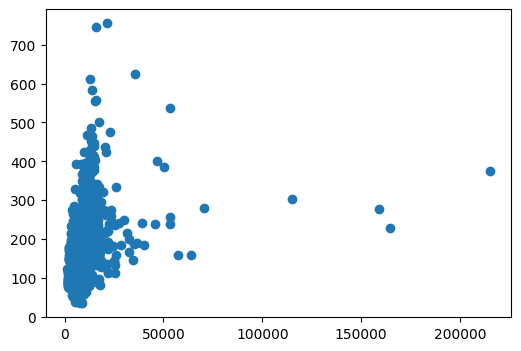

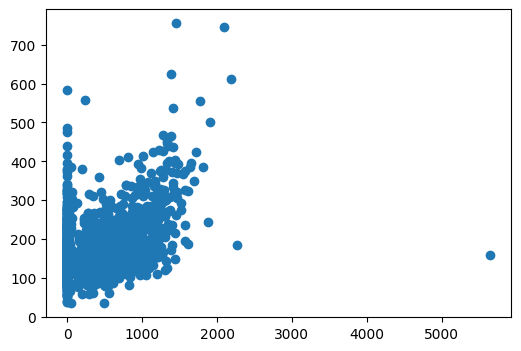

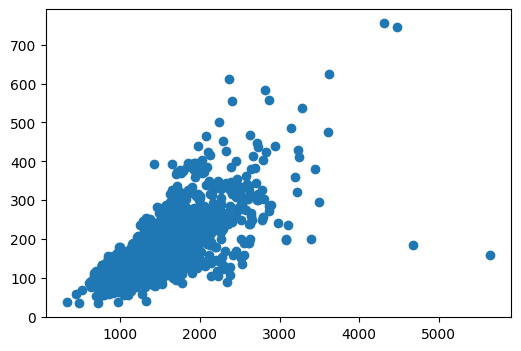

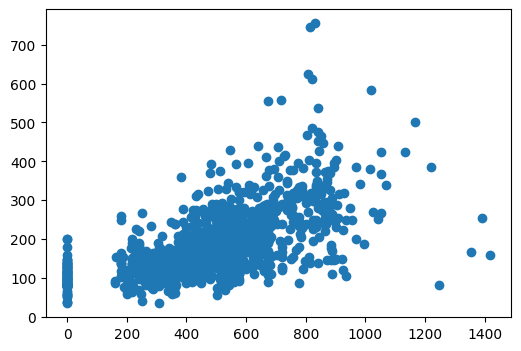

In [12]:
# Scatterplots

for col in continuous_vars:
    plt.figure(figsize=(6,4))
    plt.scatter(data=df, x=col, y=target)
    plt.show()

In [13]:
# log transform for skwed variables

df["LogLotArea"] = np.log(df["LotArea"])
df["LogLivAreaSF"] = np.log(df["LivAreaSF"])

In [14]:
# Group Categorical Variables

def group_garagecars(x):
    if x == 0:
        return "0"
    elif x <= 2:
        return "1-2"
    else:
        return "3+"

df["GarageCarsGroup"] = df["GarageCars"].apply(group_garagecars)

garage_dummies = pd.get_dummies(df["GarageCarsGroup"], drop_first=True)

In [15]:
# Initial Model Variables

X = pd.concat([
    df[
        [
            "LogLotArea",
            "BsmtFinSF",
            "LogLivAreaSF",
            "GarageSF",
            "TotalRms",
            "Bathrooms",
            "Fireplaces"
        ]
    ],
    garage_dummies
], axis=1)

y = df[target]

In [16]:
# Remove any missing values

data = pd.concat([X, y], axis=1).dropna()

X = data.drop(columns=[target])
y = data[target]

In [17]:
# Backwards Elimination Function

def backward_elimination(X, y, significance_level=0.05):
    X = sm.add_constant(X)

    while True:
        model = sm.OLS(y, X).fit()
        pvalues = model.pvalues.drop("const")

        max_p = pvalues.max()

        if max_p > significance_level:
            excluded_feature = pvalues.idxmax()
            print(f"Removing: {excluded_feature} (p = {max_p:.4f})")
            X = X.drop(columns=[excluded_feature])
        else:
            break

    return model


In [19]:
# Backwards Regression

# Convert X to float to handle boolean columns from get_dummies
X = X.astype(float)

final_model = backward_elimination(X, y)

print("\nFinal Model Summary:\n")
print(final_model.summary())

print("\nR-squared:", final_model.rsquared)
print("Adjusted R-squared:", final_model.rsquared_adj)

Removing: 1-2 (p = 0.2477)

Final Model Summary:

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     467.2
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:28:27   Log-Likelihood:                -7528.5
No. Observations:                1460   AIC:                         1.508e+04
Df Residuals:                    1451   BIC:                         1.512e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [22]:
# Predict House Price

new_house = pd.DataFrame({
    "LogLotArea": [np.log(10000)],
    "BsmtFinSF": [800],
    "LogLivAreaSF": [np.log(2500)],
    "GarageSF": [550],
    "TotalRms": [6],
    "Bathrooms": [2.5],
    "Fireplaces": [1],
    "1-2": [1],   # GarageCars = 2
    "3+": [0]
})

# Keep only variables used in final model
model_features = final_model.model.exog_names

new_house = new_house[model_features]

new_house = sm.add_constant(new_house, has_constant='add')

predicted_price_k = final_model.predict(new_house)[0]

print("\nPredicted Sale Price (in $1000s):", round(predicted_price_k, 2))
print("Predicted Sale Price ($):", round(predicted_price_k * 1000, 2))


Predicted Sale Price (in $1000s): 259.46
Predicted Sale Price ($): 259462.91
